# XGBoost

The code below trains an XGBoost classifier using the best set of hyperparameters identified through a randomized search. The model is implemented using the xgboost package. 
The performance of the best classifier is then evaluated on the test dataset, followed by a discussion of the results

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn import metrics
from sklearn.model_selection import RandomizedSearchCV

In [2]:
train = pd.read_csv('train_processed.csv')
validation = pd.read_csv('validation_processed.csv')
test = pd.read_csv('test_processed.csv')
train.head(2)

,loan_status,loan_amnt,int_rate,annual_inc,dti,open_acc,pub_rec,revol_bal,revol_util,total_acc,...,verif__Not Verified,verif__Source Verified,verif__Verified,purpose__consumer_needs,purpose__credit_card,purpose__debt_consolidation,purpose__home_improvement,purpose__other,list__f,list__w
0,0,25000.0,19.20,11.938200,6.39,9.0,0,10.150348,49.6,21.0,...,0,0,1,0,0,1,0,0,1,0
1,1,5000.0,13.67,10.686567,6.23,14.0,1,8.822470,45.8,38.0,...,1,0,0,1,0,0,0,0,0,1


In [3]:
# Features and Label
# for train 
y_train = train['loan_status']
X_train = train.iloc[:, 1:]

# for validation
y_val = validation['loan_status']
X_val = validation.iloc[:, 1:]

# for test
y_test = test['loan_status']
X_test = test.iloc[:, 1:]

In [4]:
# xgboost package is particular about symbol "<" in variables namings
X_train = X_train.rename(columns={'emp__<=2 years':'emp__lte_2_years'})
X_val = X_val.rename(columns={'emp__<=2 years':'emp__lte_2_years'})
X_test = X_test.rename(columns={'emp__<=2 years':'emp__lte_2_years'})

## Model Training and Hyperpameters Optimisation

In [5]:
#Initialise the estimator
estimator = xgb.XGBClassifier(random_state=42, 
                              eval_metric='logloss',
                              scale_pos_weight= 4, #that's the rough balance of positive and negative classess. 4:1
                              tree_method='hist')

#Hyperparameter Space for XGBoost model. I have 238K rows and 32 predictors
param = {
    'n_estimators': [100, 200, 500, 1000],
    'max_depth': [3, 5, 7, 10],
    'min_child_weight': [1, 3, 5, 10, 12],
    'subsample': [0.6, 0.8, 1.0],
    'learning_rate': [0.01, 0.05, 0.1, 0.3],
    'colsample_bytree': [0.6, 0.8, 1.0]   #feature sampling 
}

In [6]:
# Start the randomised grid search. It is compared on roc_auc rather that f1 because I check the threshold later
search = RandomizedSearchCV(estimator=estimator, param_distributions=param, n_iter=40,
    scoring='f1', cv=3, verbose=2, random_state=42, n_jobs=-1, return_train_score=True) 

search.fit(X_train, y_train)

Fitting 3 folds for each of 40 candidates, totalling 120 fits


,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.6, 0.8, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'min_child_weight': [1, 3, ...], ...}"
,n_iter,40
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [9]:
print('\nBest Hyperparameters:')
print(search.best_params_, '\n')
print(search.best_estimator_, '\n')
print('F1 score:', round(search.best_score_, 3))


Best Hyperparameters:
{'subsample': 0.8, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.6} 

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.6, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=5, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None,
              num_parallel_tree=None, ...) 

F1 score: 0.436


The model wants to learn the following way: shallow trees ('max_depth': 5) despite of the dataset having 32 predictors. Apparently, there are a lot of weak signals in the predictors and not much benefit from specific interactions. It wants small learning rate ('learning_rate': 0.05), fairly a lot of boosting rounds('n_estimators': 500). It also prefers randomness as 'subsample': 0.8 and 'colsample_bytree': 0.6 can bve read as "I want to use 80% of rows and 60% of columns for each boosting round"

In [6]:
# I copy the parameters from search.best_estimator_ because
# I do not want to run the parameters search each time when open a file
estimator_best = xgb.XGBClassifier(random_state=42, eval_metric='logloss',
                                   scale_pos_weight= 4, 
                                   tree_method='hist', subsample=0.8, min_child_weight=5, 
                                   colsample_bytree=0.6, learning_rate=0.05, n_estimators=500, max_depth=5) #early_stopping_rounds=50)

estimator_best.fit(X_train, y_train) #eval_set=[(X_val, y_val)])

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.6
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'logloss'


In [7]:
feature_importance = pd.DataFrame({'Feature': X_val.columns, 'Importance': estimator_best.feature_importances_})
feature_importance.sort_values('Importance', ascending=False).head(10)

,Feature,Importance
12,term__ 36 months,0.351426
1,int_rate,0.111108
13,term__ 60 months,0.075256
18,home__MORTGAGE,0.043397
9,mort_acc,0.043350
21,home__RENT,0.030464
22,verif__Not Verified,0.028176
3,dti,0.027856
2,annual_inc,0.023267
23,verif__Source Verified,0.020159


That's a rather interesting result. For the first time, *term* urpasses our previous strongest predictor *int_rate*. This means that XGBoost is able to capture non-linear interactions involving loan term more effectively than the other models

## Model Validation

In [8]:
y_val_score = estimator_best.predict_proba(X_val)[:, 1]
thresholds = np.arange(0.01, 1, 0.01)

best_f1 = 0
best_threshold = 0

for t in thresholds:
    pred = (y_val_score >= t).astype(int)

    f1 = metrics.f1_score(y_val, pred)

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print('The best Classification Threshold:', round(best_threshold, 3))
print('The best F1 score:', round(best_f1, 3))

The best Classification Threshold: 0.53
The best F1 score: 0.432


In [9]:
# Apply the same classification threshold to the training dataset for a fair comparison
y_train_score = estimator_best.predict_proba(X_train)[:,1]
y_train_pred = (y_train_score >= 0.53).astype(int)

y_val_pred = (y_val_score >= 0.53).astype(int)

print('Train Confusion Matrix: \n', metrics.confusion_matrix(y_train, y_train_pred), '\n')
print('Train Recall:', round(metrics.recall_score(y_train, y_train_pred), 3))
print('Train Precision:', round(metrics.precision_score(y_train, y_train_pred), 3), '\n')
print('Validation Confusion Matrix: \n', metrics.confusion_matrix(y_val, y_val_pred), '\n')
print('Validation Recall:', round(metrics.recall_score(y_val, y_val_pred), 3))
print('Validation Precision:', round(metrics.precision_score(y_val, y_val_pred), 3), '\n')

print('F1 score train:', round(metrics.f1_score(y_train, y_train_pred), 3))
print('F1 score validation:', round(metrics.f1_score(y_val, y_val_pred), 3))

Train Confusion Matrix: 
 [[138448  53006]
 [ 17111  29977]] 

Train Recall: 0.637
Train Precision: 0.361 

Validation Confusion Matrix: 
 [[29426 11600]
 [ 4114  5976]] 

Validation Recall: 0.592
Validation Precision: 0.34 

F1 score train: 0.461
F1 score validation: 0.432


The F1 score decreased slightly, but the model still generalises fairly well

## Model Testing

In [10]:
y_test_score = estimator_best.predict_proba(X_test)[:,1]
y_test_pred = (y_test_score >= 0.53).astype(int)

In [11]:
print('Test Confusion Matrix: \n', metrics.confusion_matrix(y_test, y_test_pred), '\n')
print('Test Recall:', round(metrics.recall_score(y_test, y_test_pred), 3))
print('Test Precision:', round(metrics.precision_score(y_test, y_test_pred), 3), '\n')
print('F1 score test:', round(metrics.f1_score(y_test, y_test_pred), 3))

Test Confusion Matrix: 
 [[29225 11802]
 [ 3980  6110]] 

Test Recall: 0.606
Test Precision: 0.341 

F1 score test: 0.436


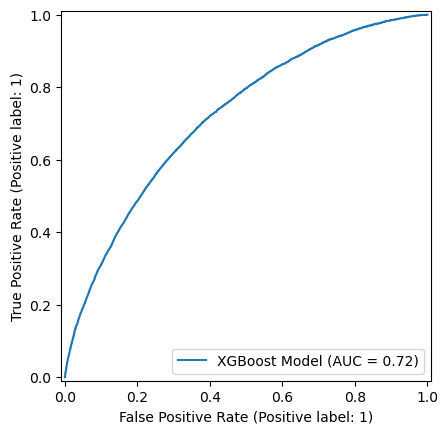

In [12]:
metrics.RocCurveDisplay.from_predictions(y_test, y_test_score, name='XGBoost Model')
plt.show()

## Conclusion

XGBoost achieved the best performance among all models tested, with an F1 score of 0.436, although the improvement over Logistic Regression and Random Forest is relatively modest. Nevertheless, it is the first model to demonstrate a meaningful gain from modelling more complex relationships within the data.

An interesting observation is that, unlike the previous models, which relied primarily on economically intuitive numerical features such as interest rate, income, and debt-to-income ratio, XGBoost places greater importance on categorical variables, particularly loan term and home ownership. This means that the model is able to capture non-linear relationships and interactions between these categorical features and the probability of default.

Compared with the baseline Logistic Regression model, XGBoost achieves a slightly lower recall (60.6% vs 65.5%) but a higher precision (34.1% versus 31.3%). Meaning that the model identifies slightly fewer defaulters, but a larger proportion of the loans it classifies as defaults are indeed defaults. 

Overall, the results suggest that while most of the predictive signal in the dataset can be captured by relatively simple models, XGBoost is able to extract additional information from complex feature interactions and therefore delivers the strongest predictive performance.

**Top Predictors:**

| Feature | Importance | 
|:-----------|:------------:|
| term__ 36 months   |  0.351426   | 
| int_rate     |  0.111108 | 
| term__ 60 months|0.075256|
| home__MORTGAGE |0.043397|
| mort_acc | 0.043350|

**Summary of the Test Metrics:**

| Metrics | Model Performance | 
|:-----------|:------------:|
| F1 Score   |  0.436   | 
| Precision        |  0.341 | 
| Recall|0.606|
| AUC |0.72|